In [1]:
import numpy as np
import matplotlib.pyplot as plt

from field_lines import PeriodicInterpolator, integrate_lines, unwrap_lines, plot_field_lines
from cubes import set_r_cube, set_k_cube
from generate_goldreich_sridhar import get_aniso_cube

# Semi-analytical Magnetic Field Approach

## Description

#### 1. Magnetic field geometry

- Trace the magnetic field line from the source.
- Compute:
  - field-line coordinate $s$,
  - magnetic field strength $B(s)$,
  - observer pitch-angle cosine
    $
    \mu_{\mathrm{obs}}(s) = \hat{\mathbf b}(s)\cdot\hat{\mathbf n}_{\mathrm{obs}}.
    $

#### 2. Observer solutions

For every position $s$:

$$\mu_\pm(s)=\pm\sqrt{1-(1-\mu_0^2)\frac{B(s)}{B_0}}.$$

- Solve $\mu_\pm(s,\mu_0)=\mu_{\mathrm{obs}}(s)$
  for all possible $\mu_0$.

#### 3. Classify trajectories

For each solution:

- **Passing**
  - $s_{\max}=S_{\max}$
  - No mirror before reaching the observer.

- **Reflected**
  - $s_{\max}<S_{\max}$
  - Particle reaches the observer after one mirror reflection.

- **Trapped**
  - Both $s_{\min}$ and $s_{\max}$ are finite.
  - Particle undergoes repeated mirror bounces.

#### 4. Transport

Apply the corresponding propagation model:

- Passing → single-pass propagation.
- Reflected → single-mirror propagation.
- Trapped → repeated-bounce / confinement model.

#### 5. Emission

- Compute the electron distribution.
- Calculate the corresponding IC gamma-ray emissivity.
- Integrate along the line of sight to obtain the predicted morphology and spectrum.

## 1. Magnetic field geometry

### 1.1. Cube

In [2]:
L = 300  # [pc], half-size
n_side = 256
dx = 2*L/n_side # [pc], cell size
k_min = 2*np.pi / (2*L)  # [pc-1], injection scale
print(f"Each cell is a cube with size dx = {dx:.2f} pc")
print(f"Injection scale (2pi/k_min) is {2*np.pi/k_min:.2f} pc")

r_cube = set_r_cube(n_side, L)
k_cube = set_k_cube(n_side, L)
b_cube = get_aniso_cube(n_side, L, k_min, 'YL02')  # normalized isotropic field

Each cell is a cube with size dx = 2.34 pc
Injection scale (2pi/k_min) is 600.00 pc


In [3]:
eta = 1.0

b0 = 1 / np.sqrt(1 + eta**2)

b_turb = eta / np.sqrt(1 + eta**2) * b_cube

b_cube_10 = b_turb
b_cube_10[..., 2] += b0

### 1.2. Lines and field strength

1280


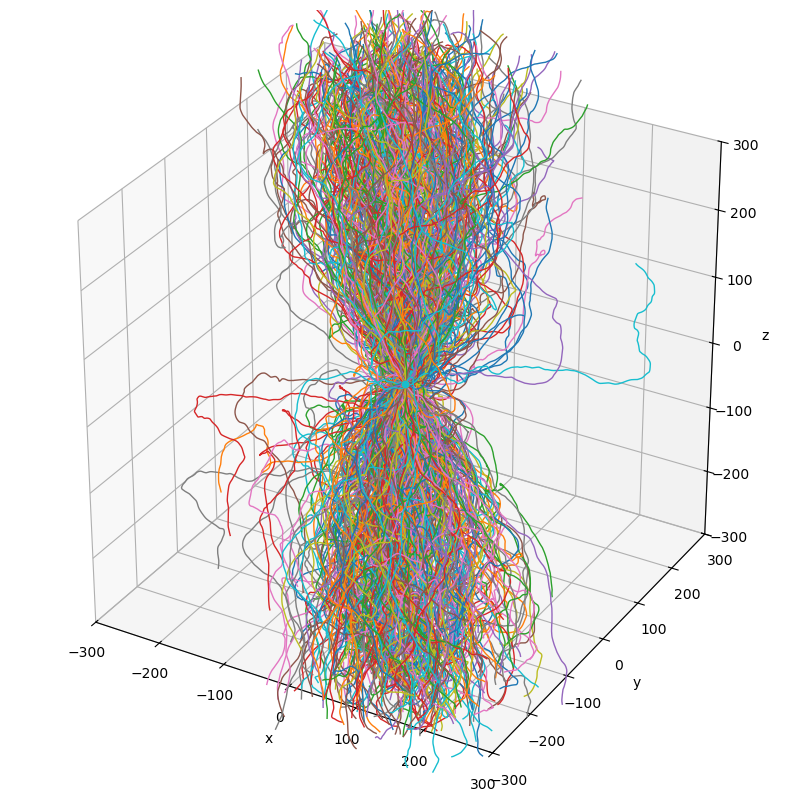

In [4]:
periodic_interpolator = PeriodicInterpolator(r_cube, b_cube_10)
N_lines = 400
ds = dx / 5
n_steps = int(2 * L / ds)  # n_steps
N_steps = 2 * n_steps + 1

# calculate field lines
lines = integrate_lines(periodic_interpolator, N_lines, n_steps, ds)

# calculate magnetic fields along the line
fields = np.zeros([2*n_steps + 1, N_lines, 3])
for i in range(N_lines):
    fields[:, i, :] = periodic_interpolator(lines[:, i])

# now shift the lines to 0
lines_from_zero = unwrap_lines(lines - lines[n_steps], 2 * L)
print(n_steps)
plot_field_lines(
    lines_from_zero,
    n_lines=N_lines,
    box_size=L
)
plt.tight_layout()
plt.show()

In [5]:
s_line = np.linspace(-ds * n_steps, ds * n_steps, N_steps)
B = np.linalg.norm(fields, axis=-1)

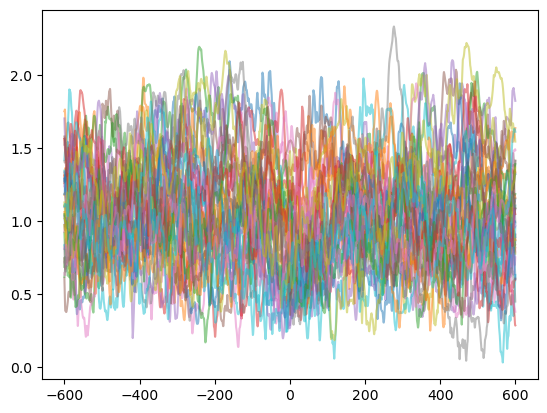

In [6]:
plt.plot(s_line, B[:, ::10], alpha=.5)
plt.show()

### 1.3. Observer

Observer is set to be in the $xz$-plane.

Its position is parametrized by angle $\phi_\mathrm{obs}$, such that
$$ \hat{n} = (\sin\phi, 0, \cos\phi) $$

In [7]:
N_obs = 36  # each 10 degrees
phi_obs = np.linspace(0, 2 * np.pi, N_obs, endpoint=False)  # observer angles
n_hat = np.array([np.sin(phi_obs), np.zeros_like(phi_obs), np.cos(phi_obs)])  # observer directions

Calculate unit vectors $\hat{b}$ along the lines.

In [8]:
b_hat = fields / B[..., None]

And calculate the observing angle $\mu_\mathrm{obs}(s) = (\hat{n}, \hat{\mu})$.

In [9]:
mu_obs = np.dot(b_hat, n_hat)
mu_obs.shape

(2561, 400, 36)

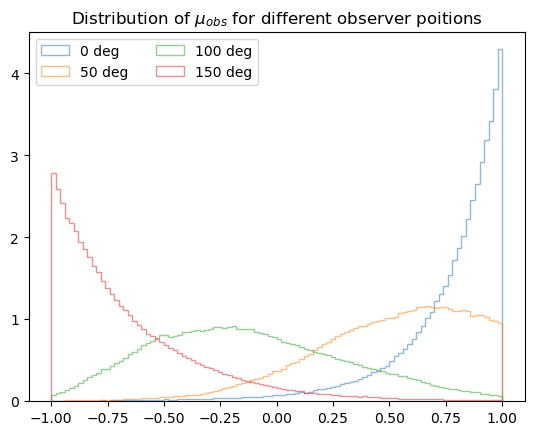

In [10]:
plt.title(r"Distribution of $\mu_{obs}$ for different observer poitions")
for i_obs in range(0, N_obs//2+1, 5):
    plt.hist(mu_obs[..., i_obs].ravel(), bins=100, density=True, alpha=.5, label=f"{np.rad2deg(phi_obs[i_obs]):.0f} deg", histtype='step')
plt.legend(ncol=2)
plt.show()

## 2. Observer solutions

Define $I_0 = (1-\mu_0^2)/B_0 = (1 - \mu^2(s))/B(s)$.

Then $\mu^2 = 1 - I_0 B(s) = 1 - (1 - \mu_0^2)/B_0$, which gives

$\mu_0^2 = 1 - I_0 B_0 $.

If $\mu_0^2 < 0$, no solutions are possible.

If $\mu_0^2 > 0$, we find two possible angles: $\mu_{0+}$ and $\mu_{0-}$.

In [11]:
I0 = (1 - mu_obs**2) / B[..., None]
B0 = B[n_steps, ...]

mu0_2 = 1 - I0 * B0[None, :, None]**2

In [12]:
mu0_2 = 1.0 - (
    B0[None, :, None] / B[:, :, None]
) * (1.0 - mu_obs**2)

# Inaccessible solutions
mu0_2[mu0_2 < 0.0] = np.nan

mu0_abs = np.sqrt(mu0_2)

mu0_plus = mu0_abs
mu0_minus = -mu0_abs

## 3. Trajectory classification

There may be four cases for each point

* **Passing**

    The particle is passing if there is no mirror between the source and the observer.

    *Condition*: $\mu_0 \cdot \mu_\mathrm{obs} > 0$ + no mirror between the source and the observer + no mirror after the observer

* **Reflected**
    The particle reflected once and passes the observer without a following reflection.

    *Condition*: $\mu_0 \cdot \mu_\mathrm{obs} < 0$ + mirror beyond the source + no mirror after the source.

* **Trapped**
    The particle is in the magnetic bottle.

* **False**
    The position can't be reached because of a mirror between the source and the observer

Let

- **BTW** — Mirror **between the source and the observer**
- **AFTER** — Mirror **after the observer**
- **BEFORE** — Mirror **before the source**

In [13]:
# for s > 0

empty_true = np.ones_like(mu0_2) 
left = np.bool((s_line >= 0)[:, None, None] * empty_true)

# from source to observer
Bmax_between_fwd = np.maximum.accumulate(B[n_steps:, :], axis=0)
Bmax_between_bck = np.maximum.accumulate(B[:n_steps, :][::-1], axis=0)[::-1]

Bmax_between = np.vstack((Bmax_between_bck, Bmax_between_fwd))

# from right (left) end to observer
Bmax_after_fwd = np.maximum.accumulate(B[n_steps:, :][::-1], axis=0)[::-1]
Bmax_after_bck = np.maximum.accumulate(B[:n_steps, :], axis=0)

Bmax_after = np.vstack((Bmax_after_bck, Bmax_after_fwd))

# beyond the source
Bmax_beyond_fwd = np.max(B[:n_steps, :], axis=0)
Bmax_beyond_bck = np.max(B[n_steps:, :], axis=0)

Bmax_beyond = (Bmax_beyond_fwd[None, :] * (s_line >= 0)[:, None] + Bmax_beyond_bck[None, :] * (s_line < 0)[:, None])

In [14]:
# ! Bmax_between is observer-independent!
print(Bmax_between.shape)   # (N_steps, N_lines)
print(Bmax_after.shape)     # (N_steps, N_lines)
print(Bmax_beyond.shape)    # (N_steps, N_lines)

(2561, 400)
(2561, 400)
(2561, 400)


**Forward branch $\mu_\mathrm{obs}\times s > 0$**

| BTW | A | B | Class |
|:---:|:---:|:---:|:----------------|
| Y | * | * | False |
| N | Y | Y | Trapped |
| N | * | N | Passing |
| N | N | Y | Passing / Reflected |

**Backward branch $\mu_\mathrm{obs}\times s < 0$**

| BTW | A | B | Class |
|:---:|:---:|:---:|:---------|
| Y | * | * | False |
| N | Y | Y | Trapped |
| N | Y | N | Reflected |
| N | N | * | False |

In [15]:
FWD = mu_obs * s_line[:, None, None] > 0  # *forward* switch

In [16]:
B_mirror = B0[None, :, None] / (1 - mu0_2)

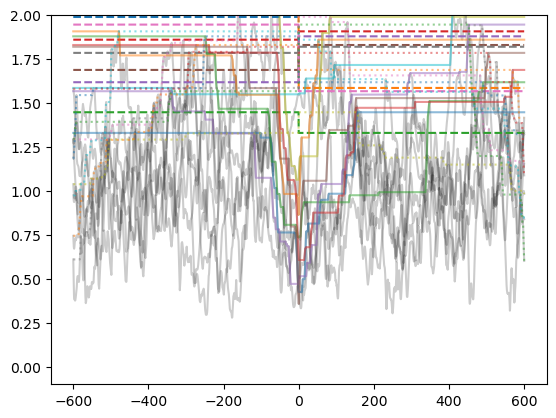

In [17]:
plt.plot(s_line, B[:, ::50], color='black', alpha=0.2)
plt.plot(s_line, Bmax_beyond[:, ::50], linestyle='dashed')
plt.plot(s_line, Bmax_between[:, ::50], alpha=.5)
plt.plot(s_line, Bmax_after[:, ::50], alpha=.5, linestyle='dotted')
plt.ylim(-0.1, 2.0)
plt.show()

In [18]:
### The mirror-in-between condition
BTW = (Bmax_between[..., None] - B_mirror) >= 0  # between maximum > mirror
###
AFTER = (Bmax_after[..., None] - B_mirror) >= 0         # mirror after
BEFORE = (Bmax_beyond[..., None] - B_mirror) >= 0        # mirror beyond

In [19]:
passing = np.bool(FWD * (1-BTW)) * ((1-BEFORE) + (1-AFTER) * BEFORE)
reflected = np.bool((1-BTW) * (FWD * (1-AFTER) * BEFORE + (1-FWD) * AFTER * (1-BEFORE)))
trapped = np.bool((1-BTW) * AFTER * BEFORE)

In [48]:
nl = 6
nobss = np.arange(0, 31, 2)
Nobs = len(nobss)
nsep = 2

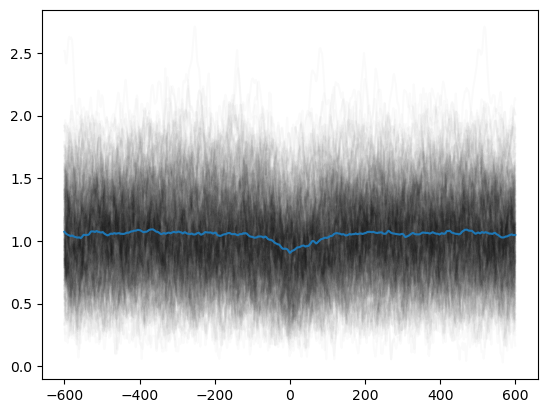

In [49]:
plt.plot(s_line, B, color='black', alpha=0.02)
plt.plot(s_line, np.mean(B, axis=1))

1280


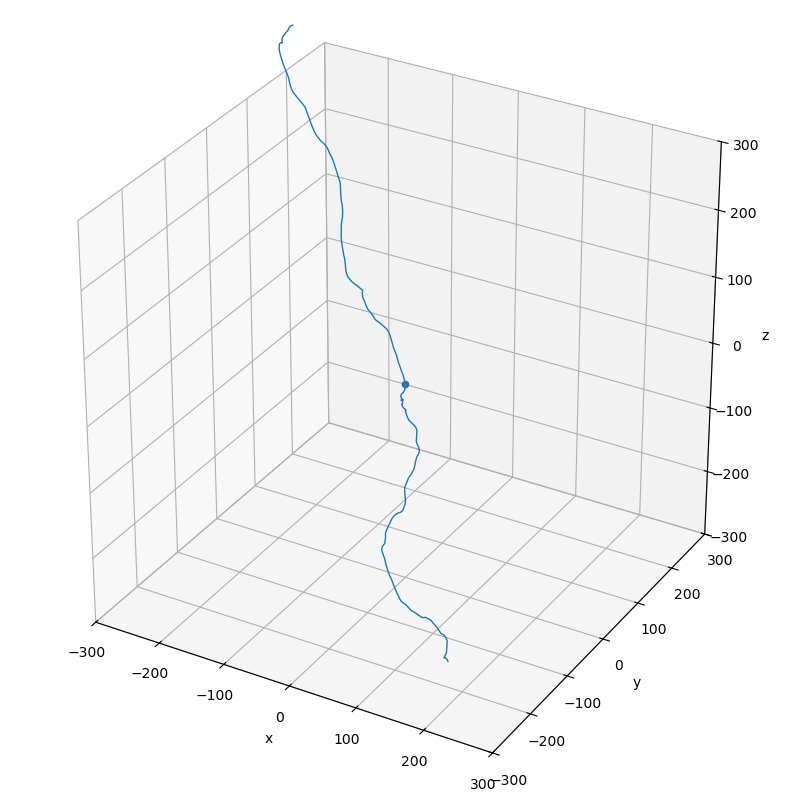

In [50]:
# now shift the lines to 0
lines_from_zero = unwrap_lines(lines - lines[n_steps], 2 * L)
print(n_steps)
plot_field_lines(
    lines_from_zero[:, nl:nl+1],
    n_lines=1,
    box_size=L
)
plt.tight_layout()
plt.show()

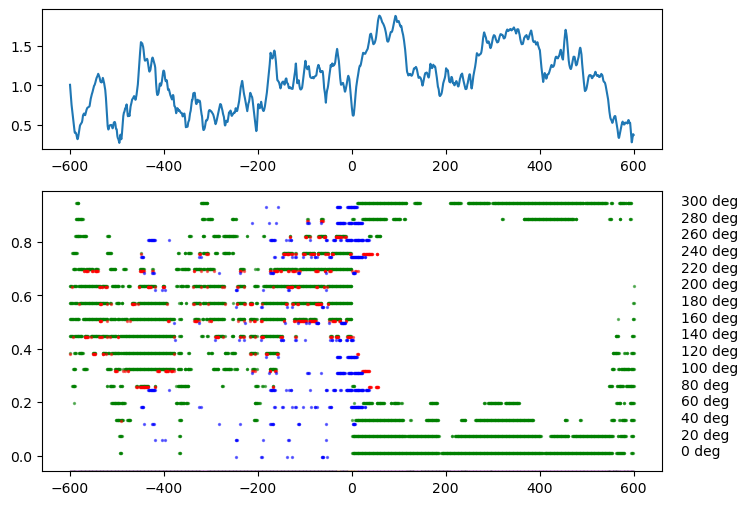

In [51]:
s = 2

colors = ['green', 'red', 'blue']

fig = plt.figure(figsize=(8, 6))
gs = plt.GridSpec(2, 1, fig, height_ratios=[1, 2])
plt.subplot(gs[0])
plt.plot(s_line, B[:, nl])

plt.subplot(gs[1])
for i, nobs in enumerate(nobss):
    plt.scatter(s_line[::nsep], 1/Nobs * i + 1.010 * passing[::nsep, nl, nobs] - 1,
                s=s, alpha=.5, color='green')
    plt.scatter(s_line[::nsep], 1/Nobs * i + 1.005 * reflected[::nsep, nl, nobs] - 1,
                s=s, alpha=.5, color='red')
    plt.scatter(s_line[::nsep], 1/Nobs * i + 0.995 * trapped[::nsep, nl, nobs] - 1,
                s=s, alpha=.5, color='blue')
    plt.text(700, 1/Nobs * i, f"{np.rad2deg(phi_obs[nobs]):.0f} deg")

plt.ylim(-1/(Nobs+1), 0.99)
plt.show()